<a href="https://colab.research.google.com/github/indrap23/PJJDA/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


The integer labels correspond to the following 10 classes:

0: airplane

1: automobile

2: bird

3: cat

4: deer

5: dog

6: frog

7: horse

8: ship

9: truck

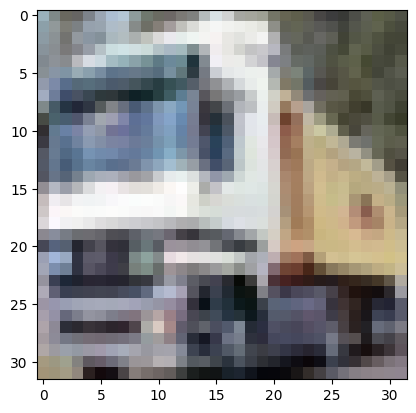

[9]


In [10]:
#contoh gambarnya
plt.imshow(x_train[1])
plt.show()
print(y_train[1])


Scaling:

Data gambar perlu dinormalisasi sebelum dimasukkan ke dalam model neural network. Gambar dalam format RGB memiliki nilai piksel antara 0 hingga 255. Normalisasi dilakukan dengan membagi setiap nilai piksel dengan 255.0 agar rentang nilainya menjadi $0$ hingga $1$. Hal ini membantu model belajar lebih cepat dan stabil.


One-hot encoding: Converts the labels (0-9) into a one-hot vector (e.g., for label 2: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]).





In [19]:
#Normalisasi nilai piksel menjadi 0 hingga 1
x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

##Modeling

CNN adalah jenis neural network yang dirancang khusus untuk memproses data grid seperti gambar.

<img src="https://encrypted-tbn2.gstatic.com/licensed-image?q=tbn:ANd9GcSkeE3lpDuLkPZM1ESYYyCEU6kd4rIXtxLnuFWCFKUQXoNzdancuE50O4leexYuKpppSr5weMyCC1ys4gdrDm9C3WNZ40n9rCvMVeYLyOfZFQYmeQM">


Conv2D (Convolutional Layer): Mengekstrak fitur dari gambar (seperti garis, sudut, tekstur) menggunakan matriks filter.

MaxPooling2D: Mengurangi dimensi spasial gambar untuk mengurangi beban komputasi dan mencegah overfitting.

Flatten: Mengubah matriks 2D menjadi vektor 1D agar bisa dimasukkan ke layer neural network standar.

Dense (Fully Connected Layer): Layer klasifikasi akhir yang memetakan fitur yang diekstrak ke dalam 10 kelas probabilitas output.


In [13]:
# Membangun arsitektur model CNN
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
625/625 - 81s - 129ms/step - accuracy: 0.4584 - loss: 1.4915 - val_accuracy: 0.5622 - val_loss: 1.2173
Epoch 2/15
625/625 - 77s - 124ms/step - accuracy: 0.6108 - loss: 1.1063 - val_accuracy: 0.6446 - val_loss: 1.0127
Epoch 3/15
625/625 - 78s - 124ms/step - accuracy: 0.6748 - loss: 0.9276 - val_accuracy: 0.6780 - val_loss: 0.9296
Epoch 4/15
625/625 - 82s - 132ms/step - accuracy: 0.7145 - loss: 0.8157 - val_accuracy: 0.6985 - val_loss: 0.8758
Epoch 5/15
625/625 - 77s - 124ms/step - accuracy: 0.7427 - loss: 0.7368 - val_accuracy: 0.7226 - val_loss: 0.8156
Epoch 6/15
625/625 - 78s - 124ms/step - accuracy: 0.7708 - loss: 0.6628 - val_accuracy: 0.7220 - val_loss: 0.8150
Epoch 7/15
625/625 - 82s - 131ms/step - accuracy: 0.7911 - loss: 0.6005 - val_accuracy: 0.7190 - val_loss: 0.8369
Epoch 8/15
625/625 - 82s - 131ms/step - accuracy: 0.8134 - loss: 0.5332 - val_accuracy: 0.7066 - val_loss: 0.8834
Epoch 9/15
625/625 - 77s - 124ms/step - accuracy: 0.8314 - loss: 0.4810 - val_accuracy: 

In [15]:
#evaluating model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

Test accuracy = 0.703


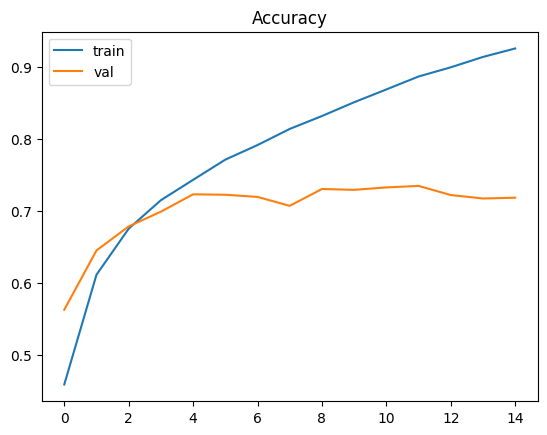

In [20]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()